### Import Required Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from numpy import mean
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import math

### Importing the data from excel

In [56]:
df=pd.read_excel("train.xlsx")

In [57]:
df.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [58]:
df.shape

(45211, 17)

In [59]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

### Checking for null values

In [60]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### Check on Target variable

In [61]:
df["y"].value_counts()

no     39922
yes     5289
Name: y, dtype: int64

In [62]:
df['target']=np.where(df['y']=="yes",1,0)

In [63]:
df=df.drop(['y'],axis=1)

In [64]:
Y=df[['target']]
X=df.drop(['target'],axis=1)

In [65]:
X['month'].value_counts()

may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: month, dtype: int64

## changing the job ,day and month

In [66]:
X['job']=X['job'].replace(['housemaid','entrepreneur'],'self-employed') #since the housemaid and entrepreneur have 
# very low percentage,so we are converting into self-employed

In [67]:
X['job'].replace(['unemployed','student'],'unknown',inplace=True)

In [68]:
# conds=[X['month'].all() in ['jan','feb','mar'],
#       X['month'].all() in ['apr','may','jun'],
#        X['month'].all() in ['jul','aug','sep'],
#       X['month'].all() in ['oct','nov','dec']]
# conds=[X['month'] == 'jan',
#       X['month'] == 'apr',
#        X['month'] == 'jul',
#       X['month'] == 'oct']
# choices=['q1','q2','q3','q4']
# X['quartile']=np.select(conds,choices)
# To reduce the labels creating a new column
X['quartile']=list(map(lambda t:'q3' if t in ['jan','feb','mar'] 
                       else ('q1' if t in ['apr','may','jun'] 
                             else ('q2' if t in ['jul','aug','sep'] else 'q4')) ,X['month']))

In [69]:
X["monthDays"]=list(map(lambda t:'1st' if t in range(0,8)
                       else ('2nd' if t in range(8,16)
                             else ('3rd' if t in range(16,24) else '4th')) ,X['day']))

In [70]:
X['monthDays'].value_counts()

3rd    14041
2nd    12145
1st     9798
4th     9227
Name: monthDays, dtype: int64

In [71]:
# X.groupby('month').count()

## Dropping columns

In [72]:
X.drop(['default','loan','pdays','previous','poutcome','month','day'],axis=1,inplace=True)

### separating numerical and object variables

In [73]:
num=X.select_dtypes(include="number")
char=X.select_dtypes(include="object")

In [74]:
num.tail()

,age,balance,duration,campaign
45206,51,825,977,3
45207,71,1729,456,2
45208,72,5715,1127,5
45209,57,668,508,4
45210,37,2971,361,2


In [75]:
char.head()

,job,marital,education,housing,contact,quartile,monthDays
0,management,married,tertiary,yes,unknown,q1,1st
1,technician,single,secondary,yes,unknown,q1,1st
2,self-employed,married,secondary,yes,unknown,q1,1st
3,blue-collar,married,unknown,yes,unknown,q1,1st
4,unknown,single,unknown,no,unknown,q1,1st


In [76]:
char.shape

(45211, 7)

### Looking for outliers

In [77]:
num.describe(percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.85,0.9,0.99])

,age,balance,duration,campaign
count,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,258.163080,2.763841
std,10.618762,3044.765829,257.527812,3.098021
min,18.000000,-8019.000000,0.000000,1.000000
1%,23.000000,-627.000000,11.000000,1.000000
5%,27.000000,-172.000000,35.000000,1.000000
10%,29.000000,0.000000,58.000000,1.000000
25%,33.000000,72.000000,103.000000,1.000000
50%,39.000000,448.000000,180.000000,2.000000
75%,48.000000,1428.000000,319.000000,3.000000


## Capping and flooring of outliers

In [78]:
def outlier_cap(x):
    x=x.clip(lower=x.quantile(0.01))
    x=x.clip(upper=x.quantile(0.99))
    return(x)

In [79]:
num=num.apply(lambda x : outlier_cap(x))

In [80]:
num.describe(percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.85,0.9,0.99])

,age,balance,duration,campaign
count,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.887660,1278.121689,254.375993,2.691403
std,10.384267,2249.406970,234.779511,2.585740
min,23.000000,-627.000000,11.000000,1.000000
1%,23.000000,-627.000000,11.000000,1.000000
5%,27.000000,-172.000000,35.000000,1.000000
10%,29.000000,0.000000,58.000000,1.000000
25%,33.000000,72.000000,103.000000,1.000000
50%,39.000000,448.000000,180.000000,2.000000
75%,48.000000,1428.000000,319.000000,3.000000


In [81]:
discrete=KBinsDiscretizer(n_bins=5,encode='ordinal', strategy='quantile')
num_binned=pd.DataFrame(discrete.fit_transform(num),index=num.index, columns=num.columns).add_suffix('_Rank')
num_binned.head()

C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\sklearn\preprocessing\_discretization.py:230: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(


,age_Rank,balance_Rank,duration_Rank,campaign_Rank
0,4.0,4.0,3.0,0.0
1,3.0,1.0,2.0,0.0
2,1.0,0.0,0.0,0.0
3,3.0,3.0,1.0,0.0
4,1.0,0.0,2.0,0.0


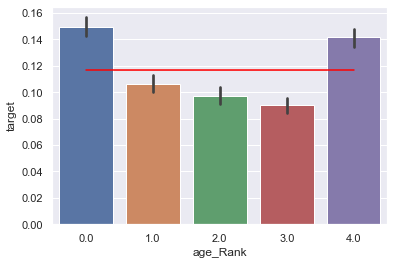

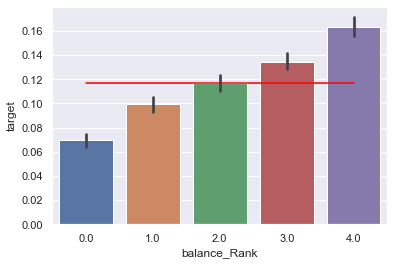

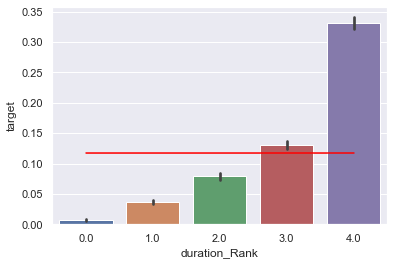

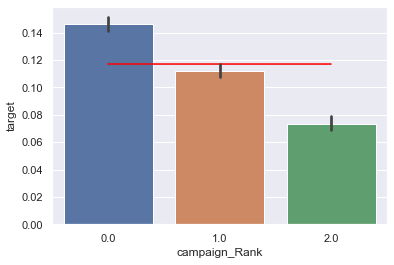

In [82]:
X_bin_combined=pd.concat([Y,num_binned],axis=1,join='inner')
for col in (num_binned.columns):
    plt.figure()
    sns.lineplot(x=col,y=X_bin_combined['target'].mean(),data=X_bin_combined,color='red')
    sns.barplot(x=col, y="target",data=X_bin_combined, estimator=mean )
plt.show()

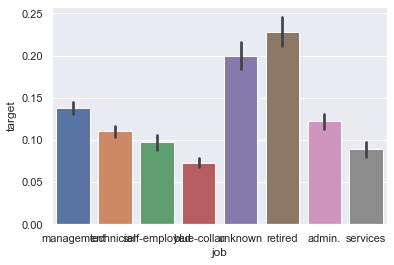

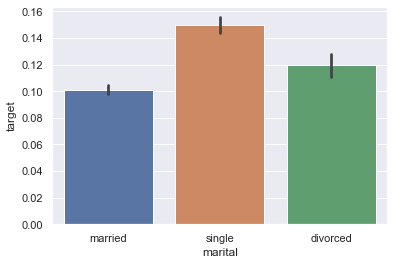

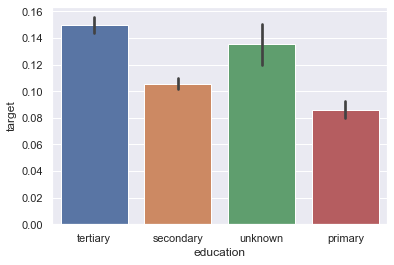

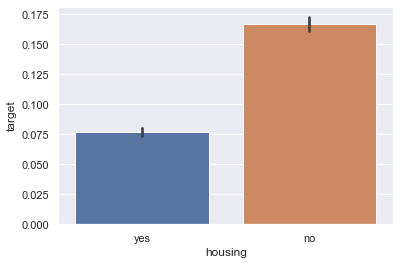

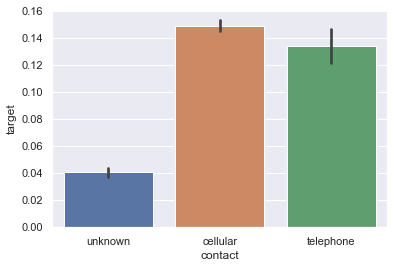

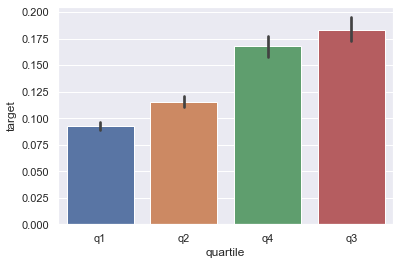

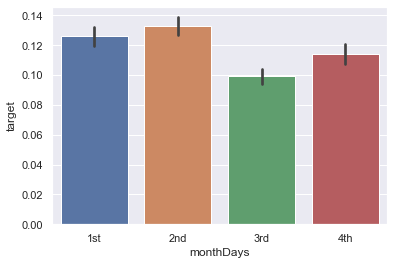

In [83]:
X_char_merged=pd.concat([Y,char],axis=1,join='inner')
for col in (char.columns):
    plt.figure()
    sns.barplot(x=col, y="target",data=X_char_merged, estimator=mean )
plt.show()

In [84]:
# Create dummy features with n-1 levels
X_char_dum = pd.get_dummies(char, drop_first = True)
X_char_dum.shape

(45211, 21)

## ILATE Feature Transformation

In [85]:
ilate_input=num[['balance','duration']]
# ilate_input.head()
# num['balance_inverse']=1/num['balance']
# num['balance_log']=np.log(num['balance'])
# num.head()
# num_binned=pd.DataFrame(discrete.fit_transform(num),index=num.index, columns=num.columns).add_suffix('_Rank')
ilate_input_inverse=pd.DataFrame(1/ilate_input,index=ilate_input.index, columns=ilate_input.columns).add_suffix('_inverse') 
ilate_input_log=pd.DataFrame(1/np.log(ilate_input),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_log') 
ilate_input_square=pd.DataFrame(np.power(ilate_input,2),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_square')
ilate_input_cube=pd.DataFrame(np.power(ilate_input,3),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_cube')
ilate_input_sqroot=pd.DataFrame(np.sqrt(ilate_input),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_sqroot')
ilate_input_cuberoot=pd.DataFrame(np.power(ilate_input,1/3),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_cuberoot')
ilate_input_sine=pd.DataFrame(np.sin(ilate_input),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_sine')
ilate_input_cos=pd.DataFrame(np.cos(ilate_input),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_cos')
ilate_input_exp=pd.DataFrame(np.exp(ilate_input),index=ilate_input.index, columns=ilate_input.columns).add_suffix('_exp')

C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [87]:
ilate_input_exp.head()

,balance_exp,duration_exp
0,inf,2.243158e+113
1,3.931334e+12,3.788495e+65
2,7.389056e+00,1.014800e+33
3,inf,9.017628e+39
4,2.718282e+00,9.779292e+85


In [88]:
# ilate=pd.concat([ilate_input,ilate_input_inverse,ilate_input_log,ilate_input_square,
#                 ilate_input_cube,ilate_input_sqroot,ilate_input_cuberoot,ilate_input_sine,
#                 ilate_input_cos,ilate_input_exp],axis=1,join='inner')
ilate=pd.concat([ilate_input_square,
                ilate_input_cube,ilate_input_sqroot,ilate_input_cuberoot,ilate_input_sine,
                ilate_input_cos],axis=1,join='inner')
ilate.head()#np.isinf(ilate['balance_inverse'])

,balance_square,duration_square,balance_cube,duration_cube,balance_sqroot,duration_sqroot,balance_cuberoot,duration_cuberoot,balance_sine,duration_sine,balance_cos,duration_cos
0,4592449.0,68121.0,9.841618e+09,17779581.0,46.292548,16.155494,12.892606,6.390677,0.420331,-0.245281,0.907371,-0.969452
1,841.0,22801.0,2.438900e+04,3442951.0,5.385165,12.288206,3.072317,5.325074,-0.663634,0.202150,-0.748058,0.979355
2,4.0,5776.0,8.000000e+00,438976.0,1.414214,8.717798,1.259921,4.235824,0.909297,0.566108,-0.416147,0.824331
3,2268036.0,8464.0,3.415662e+09,778688.0,38.807216,9.591663,11.462385,4.514357,-0.923505,-0.779466,-0.383587,-0.626444
4,1.0,39204.0,1.000000e+00,7762392.0,1.000000,14.071247,1.000000,5.828477,0.841471,-0.079579,0.540302,-0.996829


In [89]:
ilate.describe()

,balance_square,duration_square,balance_cube,duration_cube,balance_sqroot,duration_sqroot,balance_cuberoot,duration_cuberoot,balance_sine,duration_sine,balance_cos,duration_cos
count,4.521100e+04,4.521100e+04,4.521100e+04,4.521100e+04,41445.000000,45211.000000,41445.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,6.693315e+06,1.198273e+05,5.646782e+10,8.540109e+07,28.972699,14.591315,8.640630,5.846660,0.021141,-0.012354,0.067698,0.013828
std,2.327781e+07,2.502038e+05,2.780413e+11,2.808045e+08,24.070640,6.439755,5.215970,1.719330,0.687408,0.707191,0.722816,0.706795
min,0.000000e+00,1.210000e+02,-2.464919e+08,1.331000e+03,0.000000,3.316625,0.000000,2.223980,-0.999993,-0.999991,-1.000000,-1.000000
25%,1.876900e+04,1.060900e+04,3.732480e+05,1.092727e+06,12.083046,10.148892,5.265637,4.687548,-0.643561,-0.714876,-0.653644,-0.692896
50%,2.352250e+05,3.240000e+04,8.991539e+07,5.832000e+06,23.280893,13.416408,8.153294,5.646216,0.000000,-0.044243,0.110357,0.004426
75%,2.039184e+06,1.017610e+05,2.911955e+09,3.246176e+07,39.949969,17.860571,11.686316,6.832771,0.708383,0.696080,0.814041,0.717964
max,1.733146e+08,1.610361e+06,2.281669e+12,2.043548e+09,114.738398,35.623026,23.612349,10.826478,0.999994,0.999990,1.000000,1.000000


In [90]:
ilate.isnull().sum()

balance_square          0
duration_square         0
balance_cube            0
duration_cube           0
balance_sqroot       3766
duration_sqroot         0
balance_cuberoot     3766
duration_cuberoot       0
balance_sine            0
duration_sine           0
balance_cos             0
duration_cos            0
dtype: int64

In [91]:
np.isinf(ilate).sum()

balance_square       0
duration_square      0
balance_cube         0
duration_cube        0
balance_sqroot       0
duration_sqroot      0
balance_cuberoot     0
duration_cuberoot    0
balance_sine         0
duration_sine        0
balance_cos          0
duration_cos         0
dtype: int64

## Missing Value Imputation

In [92]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
ilate_1=pd.DataFrame(imputer.fit_transform(ilate),index=ilate.index,columns=ilate.columns)

In [93]:
ilate_1.isnull().sum()

balance_square       0
duration_square      0
balance_cube         0
duration_cube        0
balance_sqroot       0
duration_sqroot      0
balance_cuberoot     0
duration_cuberoot    0
balance_sine         0
duration_sine        0
balance_cos          0
duration_cos         0
dtype: int64

In [94]:
ilate_1.columns.shape

(12,)

## Select K-best for Numerical features

In [96]:
selector = SelectKBest(k=10)
selector.fit_transform(ilate_1, Y)
# Get columns to keep and create new dataframe with those only
cols = selector.get_support(indices=True)
select_features_ilate = ilate_1.iloc[:,cols]

C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [97]:
dict1=dict(zip(selector.feature_names_in_,selector.scores_))
dict(sorted(dict1.items(), key=lambda item: item[1]))

{'balance_sine': 0.02984261638980959,
 'duration_sine': 0.5703876853162164,
 'duration_cos': 19.012119442993242,
 'balance_cos': 19.74126055423485,
 'balance_cube': 23.982731559441902,
 'balance_square': 54.742658029981556,
 'balance_sqroot': 251.79585733344217,
 'balance_cuberoot': 282.8796410107754,
 'duration_cube': 5742.731508974823,
 'duration_square': 7665.137149635238,
 'duration_cuberoot': 7754.967813861447,
 'duration_sqroot': 8381.112485587508}

In [98]:
# select_features_ilate = ilate_1.loc[:,['duration_sqroot','balance_cuberoot']]
select_features_ilate.iloc[0]

balance_square       4.592449e+06
duration_square      6.812100e+04
balance_cube         9.841618e+09
duration_cube        1.777958e+07
balance_sqroot       4.629255e+01
duration_sqroot      1.615549e+01
balance_cuberoot     1.289261e+01
duration_cuberoot    6.390677e+00
balance_cos          9.073708e-01
duration_cos        -9.694520e-01
Name: 0, dtype: float64

## Creating the master feature set

In [99]:
X_all=pd.concat([select_features_ilate,num,num_binned,X_char_dum],axis=1,join="inner")

In [100]:
X_all.isnull().sum()

balance_square         0
duration_square        0
balance_cube           0
duration_cube          0
balance_sqroot         0
duration_sqroot        0
balance_cuberoot       0
duration_cuberoot      0
balance_cos            0
duration_cos           0
age                    0
balance                0
duration               0
campaign               0
age_Rank               0
balance_Rank           0
duration_Rank          0
campaign_Rank          0
job_blue-collar        0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_technician         0
job_unknown            0
marital_married        0
marital_single         0
education_secondary    0
education_tertiary     0
education_unknown      0
housing_yes            0
contact_telephone      0
contact_unknown        0
quartile_q2            0
quartile_q3            0
quartile_q4            0
monthDays_2nd          0
monthDays_3rd          0
monthDays_4th          0
dtype: int64

In [101]:
X_all.shape

(45211, 39)

## Train and test split

In [102]:
X_train, X_test, y_train, y_test=train_test_split(X_all, Y, test_size=0.3, random_state=99)

In [103]:
print("Shape of Training Data",X_train.shape)
print("Shape of Testing Data",X_test.shape)
print("Response Rate in Training Data",y_train.mean())
print("Response Rate in Testing Data",y_test.mean())

Shape of Training Data (31647, 39)
Shape of Testing Data (13564, 39)
Response Rate in Training Data target    0.118431
dtype: float64
Response Rate in Testing Data target    0.11361
dtype: float64


In [104]:
Y['target'].mean()

0.11698480458295547

## Logistic regression

In [105]:
logreg=LogisticRegression(random_state=99)
logreg.fit(X_train,y_train)

C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(random_state=99)

In [106]:
coeff_df=pd.DataFrame(X_all.columns)
coeff_df.columns=['features']
coeff_df["Coefficient Estimate"] = pd.Series(logreg.coef_[0])
coeff_df

,features,Coefficient Estimate
0,balance_square,-2.428708e-15
1,duration_square,-5.014314e-17
2,balance_cube,-1.815431e-12
3,duration_cube,-2.390384e-15
4,balance_sqroot,-3.462347e-20
5,duration_sqroot,-1.748910e-20
6,balance_cuberoot,-1.095970e-20
7,duration_cuberoot,-7.462439e-21
8,balance_cos,-1.208251e-22
9,duration_cos,-3.675861e-24


In [107]:
# Building a Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='gini',random_state=0)

In [108]:
np.random.seed(44)
from sklearn.model_selection import GridSearchCV
param_dist = {'max_depth': [3, 5, 6, 7], 'min_samples_split': [50, 100, 150, 200, 250] }
tree_grid = GridSearchCV(dtree, cv = 10, param_grid=param_dist,n_jobs = 3)
tree_grid.fit(X_train,y_train) 
print('Best Parameters using grid search: \n', tree_grid.best_params_)

Best Parameters using grid search: 
 {'max_depth': 7, 'min_samples_split': 250}


In [109]:
dtree=DecisionTreeClassifier(criterion='gini',random_state=99,max_depth=6,min_samples_split=200)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=6, min_samples_split=200, random_state=99)

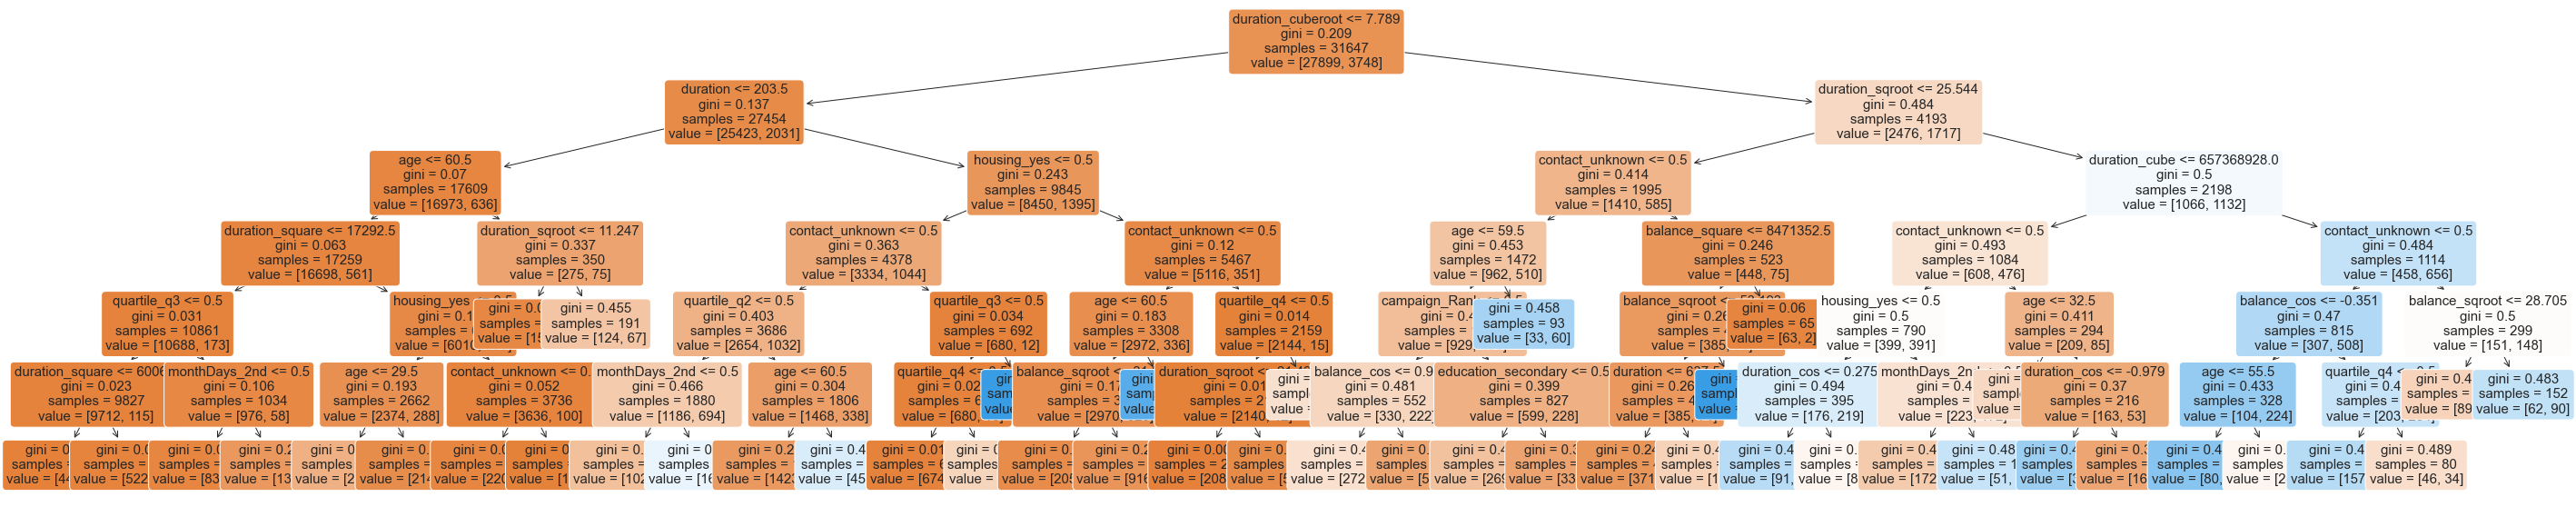

In [110]:
from sklearn import tree
import pydotplus
import matplotlib.pyplot as plt
plt.figure(figsize=[50,10])
tree.plot_tree(dtree,filled=True,fontsize=15,rounded=True,feature_names=X_all.columns)
plt.show()

In [111]:
# Building a Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion='gini',random_state=99,max_depth=6,min_samples_split=200)
rf.fit(X_train,y_train)

C:\Users\suma_\AppData\Local\Temp/ipykernel_10288/858045579.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(X_train,y_train)


RandomForestClassifier(max_depth=6, min_samples_split=200, random_state=99)

In [112]:
import pandas as pd
feature_importances=pd.DataFrame(rf.feature_importances_,
                                 index=X_train.columns,
                                 columns=['importance']).sort_values('importance',ascending=False)
feature_importances

,importance
duration_sqroot,0.181414
duration_cuberoot,0.136626
duration,0.135075
duration_cube,0.117068
duration_square,0.108509
duration_Rank,0.061040
age,0.058392
contact_unknown,0.049523
housing_yes,0.046895
balance_cube,0.011125


In [113]:
# Model Evaluation
y_pred_logreg=logreg.predict(X_test)
y_pred_tree=dtree.predict(X_test)
y_pred_rf=rf.predict(X_test)

In [114]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred_logreg))
print("Precision",metrics.precision_score(y_test,y_pred_logreg))
print("Recall",metrics.recall_score(y_test,y_pred_logreg))
print("f1_score",metrics.f1_score(y_test,y_pred_logreg))

Accuracy: 0.8173105278678856
Precision 0.040235525024533855
Recall 0.026606099935107073
f1_score 0.03203125


C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


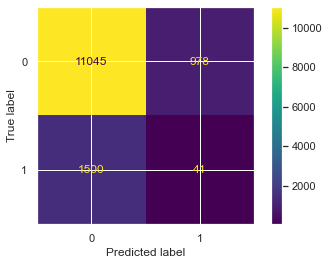

In [115]:
metrics.plot_confusion_matrix(logreg,X_test,y_test)

In [116]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred_tree))
print("Precision",metrics.precision_score(y_test,y_pred_tree))
print("Recall",metrics.recall_score(y_test,y_pred_tree))
print("f1_score",metrics.f1_score(y_test,y_pred_tree))

Accuracy: 0.892214685933353
Precision 0.5527369826435247
Recall 0.26865671641791045
f1_score 0.3615720524017467


C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


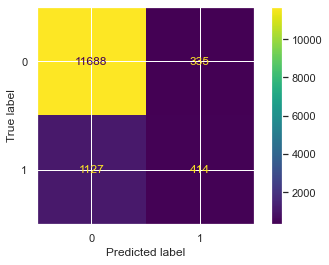

In [117]:
metrics.plot_confusion_matrix(dtree,X_test,y_test)

In [118]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred_rf))
print("Precision",metrics.precision_score(y_test,y_pred_rf))
print("Recall",metrics.recall_score(y_test,y_pred_rf))
print("f1_score",metrics.f1_score(y_test,y_pred_rf))

Accuracy: 0.8938366263639045
Precision 0.5996055226824457
Recall 0.1972744970798183
f1_score 0.296875


C:\ProgramData\Anaconda3\envs\py3-TF2.0\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


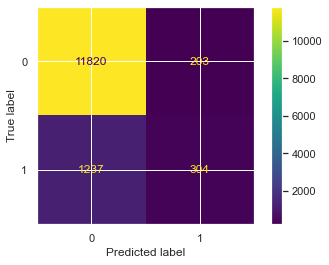

In [119]:
metrics.plot_confusion_matrix(rf,X_test,y_test)